# Nasdaq Institutional Backtest
## VWAP + Delta Hedging + Liquidity Capture + Market Structure Break + Greeks Proxies

Estrategia de alta qualidade institucional para NQ com confirmacao via SPY e QQQ.

**Filosofia:** Poucas entradas, maxima qualidade. Prefere-se perder operacoes do que gerar sinais excessivos.

**Componentes:**
- VWAP Institucional com 3 bandas de desvio padrao
- Delta Hedging Proxy via Cumulative Volume Delta (Tick Rule)
- Greeks Proxies: Delta (momentum), Gamma (aceleracao), Vanna (vol x delta)
- Captura de Liquidez com validacao de wick e recaptura
- Market Structure Break pos-liquidez
- Confluencia SPY (filtro direcional) e QQQ (alvos institucionais)
- Scoring ponderado por qualidade (0-100)

**Data:** Yahoo Finance — NQ=F (futures), SPY, QQQ — 5-min, horario de mercado (9:30-16:00 ET)

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import yfinance as yf
from pathlib import Path
from dataclasses import dataclass, field
from typing import List, Optional

plt.rcParams['figure.figsize'] = (18, 6)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10

print('Imports OK')

Imports OK


## 0. Configuracao — StrategyConfig

Todos os parametros centralizados. Ajuste aqui para calibrar a estrategia.

In [2]:
@dataclass
class StrategyConfig:
    """Parametros da estrategia institucional."""
    # ---- Assets ----
    primary: str = 'NQ=F'
    confirm_qqq: str = 'QQQ'
    confirm_spy: str = 'SPY'
    interval: str = '5m'          # '1m' or '5m'
    lookback_days: int = 59        # max for 5m on yfinance
    market_open: str = '09:30'     # ET
    market_close: str = '16:00'   # ET

    # ---- VWAP ----
    vwap_num_bands: int = 3
    vwap_band_std: float = 1.0

    # ---- Delta Hedging ----
    dh_lookback: int = 20

    # ---- Greeks ----
    delta_period: int = 10
    gamma_period: int = 10
    vanna_period: int = 20

    # ---- Liquidity Capture ----
    liq_swing_lookback: int = 20
    liq_recapture_bars: int = 5
    liq_min_wick_pct: float = 0.0008  # 0.08% min sweep

    # ---- Market Structure Break ----
    msb_swing_lookback: int = 20
    msb_break_pct: float = 0.0005     # 0.05% min break

    # ---- Scoring Weights (quality-weighted) ----
    score_liquidity: int = 30
    score_structure_break: int = 30
    score_vwap_quality: int = 20
    score_spy_aligned: int = 10
    score_qqq_aligned: int = 5
    score_momentum: int = 5

    # ---- Signal Gates ----
    min_score_to_trade: int = 80
    min_score_a: int = 85
    min_score_a_plus: int = 95
    signal_cooldown_bars: int = 15

    # ---- Risk ----
    atr_period: int = 14
    stop_mult: float = 2.0    # 2x ATR stop
    target_mult: float = 3.0  # 3x ATR target (1:1.5 R:R)
    max_trade_bars: int = 78   # 1 session = 6.5h / 5min


config = StrategyConfig()
print(f'Strategy configured: {config.primary} {config.interval}')
print(f'Stop/Target: {config.stop_mult}x/{config.target_mult}x ATR')
print(f'Min score: {config.min_score_to_trade} | A: {config.min_score_a} | A+: {config.min_score_a_plus}')

Strategy configured: NQ=F 5m
Stop/Target: 2.0x/3.0x ATR
Min score: 80 | A: 85 | A+: 95


## 1. Fetch & Align Data

Busca NQ, SPY e QQQ. Filtra para horario de mercado comum (9:30-16:00 ET).

In [3]:
def fetch_and_filter(ticker: str, cfg: StrategyConfig) -> pd.DataFrame:
    """Fetch OHLCV from yfinance, filter to market hours."""
    tk = yf.Ticker(ticker)
    df = tk.history(interval=cfg.interval, period=f'{cfg.lookback_days}d')
    if df.empty:
        raise ValueError(f'No data for {ticker}')

    df.columns = [c.lower() for c in df.columns]
    df = df.rename(columns={'open': 'Open', 'high': 'High', 'low': 'Low',
                            'close': 'Close', 'volume': 'Volume'})
    df.index = pd.to_datetime(df.index)
    if df.index.tz is not None:
        df.index = df.index.tz_convert('US/Eastern').tz_localize(None)
    df = df.between_time(cfg.market_open, cfg.market_close)
    return df


print(f'Fetching {config.primary}...')
df_nq = fetch_and_filter(config.primary, config)
print(f'  -> {len(df_nq)} bars')

print(f'Fetching {config.confirm_spy}...')
df_spy = fetch_and_filter(config.confirm_spy, config)
print(f'  -> {len(df_spy)} bars')

print(f'Fetching {config.confirm_qqq}...')
df_qqq = fetch_and_filter(config.confirm_qqq, config)
print(f'  -> {len(df_qqq)} bars')

# Align to common date range
common_start = max(df_nq.index[0], df_spy.index[0], df_qqq.index[0])
common_end = min(df_nq.index[-1], df_spy.index[-1], df_qqq.index[-1])
df_nq = df_nq.loc[common_start:common_end]
df_spy = df_spy.loc[common_start:common_end]
df_qqq = df_qqq.loc[common_start:common_end]
print(f'\nAligned: NQ={len(df_nq)}, SPY={len(df_spy)}, QQQ={len(df_qqq)}')
print(f'Period: {df_nq.index[0].date()} to {df_nq.index[-1].date()}')

Fetching NQ=F...


  -> 3871 bars
Fetching SPY...


  -> 4602 bars
Fetching QQQ...


  -> 4602 bars

Aligned: NQ=3870, SPY=3822, QQQ=3822
Period: 2026-04-30 to 2026-07-10


## 2. VWAP Institucional com Bandas

VWAP ancorado diariamente (reset a cada sessao). Bandas de desvio padrao.

In [4]:
def compute_vwap(df: pd.DataFrame, num_bands: int = 3, band_std: float = 1.0) -> pd.DataFrame:
    """Compute anchored (daily) VWAP with expanding standard deviation bands."""
    df = df.copy()
    df['_date'] = df.index.date
    df['_pv'] = df['Close'] * df['Volume']
    df['_cum_pv'] = df.groupby('_date')['_pv'].cumsum()
    df['_cum_vol'] = df.groupby('_date')['Volume'].cumsum()
    df['vwap'] = df['_cum_pv'] / df['_cum_vol'].replace(0, np.nan)

    df['_dev'] = df['Close'] - df['vwap']
    df['_std'] = df.groupby('_date')['_dev'].transform(
        lambda x: x.expanding().std().fillna(0))

    for i in range(1, num_bands + 1):
        m = band_std * i
        df[f'vwap_upper_{i}'] = df['vwap'] + m * df['_std']
        df[f'vwap_lower_{i}'] = df['vwap'] - m * df['_std']

    df['vwap_distance_pct'] = 100 * (df['Close'] - df['vwap']) / df['vwap'].replace(0, np.nan)
    df = df.drop(columns=['_date', '_pv', '_cum_pv', '_cum_vol', '_dev', '_std'])
    return df


for name, df_var in [('nq', 'df_nq'), ('spy', 'df_spy'), ('qqq', 'df_qqq')]:
    df = compute_vwap(globals()[df_var], config.vwap_num_bands, config.vwap_band_std)
    globals()[df_var] = df

print('VWAP computed for all assets')

VWAP computed for all assets


## 3. Greeks-Inspired Proxies

- **Delta** — Momentum normalizado (viés direcional, 1a derivada)
- **Gamma** — Aceleracao (2a derivada do delta) — alto gamma = potencial de aceleracao
- **Vanna** — Sensibilidade delta vs volatilidade — fluxo institucional

In [5]:
def greeks_proxies(df: pd.DataFrame, cfg: StrategyConfig) -> pd.DataFrame:
    """Compute Delta, Gamma, Vanna proxies from price/volume."""
    df = df.copy()
    close = df['Close'].astype(float)

    # Delta: normalized momentum
    df['delta_proxy'] = ((close - close.shift(cfg.delta_period))
                         / close.shift(cfg.delta_period)).fillna(0)
    df['delta_smooth'] = df['delta_proxy'].ewm(span=cfg.delta_period, adjust=False).mean()
    dmax = df['delta_smooth'].abs().rolling(cfg.delta_period * 2, min_periods=1).max()
    df['delta_norm'] = (df['delta_smooth'] / dmax.replace(0, 0.001)).clip(-1, 1).fillna(0)

    # Gamma: rate of change of delta
    df['gamma_raw'] = df['delta_smooth'].diff().fillna(0)
    gstd = df['gamma_raw'].rolling(cfg.gamma_period * 2, min_periods=1).std()
    df['gamma_norm'] = (df['gamma_raw'] / gstd.replace(0, 0.0001)).clip(-3, 3).fillna(0)
    df['gamma_magnitude'] = df['gamma_norm'].abs().rolling(cfg.gamma_period, min_periods=1).mean()

    # Vanna: delta sensitivity to volatility changes
    ret = close.pct_change().fillna(0)
    vol = ret.rolling(cfg.vanna_period, min_periods=5).std()
    df['vanna_proxy'] = (df['delta_norm'] * vol.diff()).fillna(0)

    return df


for name, df_var in [('nq', 'df_nq'), ('spy', 'df_spy'), ('qqq', 'df_qqq')]:
    df = greeks_proxies(globals()[df_var], config)
    globals()[df_var] = df

print('Greeks proxies computed for all assets')

Greeks proxies computed for all assets


## 4. Delta Hedging Proxy — Cumulative Volume Delta (Tick Rule)

Simula o comportamento de hedging dos market makers:
- **Barra Verde** (cd_zscore > +1.5) — Compra defensiva, alvo maximo
- **Barra Vermelha** (cd_zscore < -1.5) — Defesa institucional, suporte estrutural

In [6]:
def compute_delta_hedging_proxy(df: pd.DataFrame, cfg: StrategyConfig) -> pd.DataFrame:
    """Cumulative Volume Delta (Tick Rule) resetting daily."""
    df = df.copy()
    direction = np.select(
        [df['Close'] > df['Close'].shift(1), df['Close'] < df['Close'].shift(1)],
        [1, -1], default=0)
    df['_delta_vol'] = direction * df['Volume']
    df['_date'] = df.index.date
    df['cumulative_delta'] = df.groupby('_date')['_delta_vol'].cumsum()

    win = cfg.dh_lookback * 5
    cd_mean = df['cumulative_delta'].rolling(win, min_periods=1).mean()
    cd_std = df['cumulative_delta'].rolling(win, min_periods=1).std()
    df['cd_zscore'] = ((df['cumulative_delta'] - cd_mean) / cd_std.replace(0, 1)).fillna(0)

    df['dh_green_bar'] = (df['cd_zscore'] > 1.5) & (df['Close'] > df.get('vwap', df['Close']))
    df['dh_red_bar'] = (df['cd_zscore'] < -1.5) & (df['Close'] < df.get('vwap', df['Close']))
    df['dh_intensity'] = np.abs(df['cd_zscore']).clip(0, 5) * 2  # 0-10 scale

    df = df.drop(columns=['_delta_vol', '_date'])
    return df


df_nq = compute_delta_hedging_proxy(df_nq, config)
print(f'Green bars: {df_nq["dh_green_bar"].sum()}, Red bars: {df_nq["dh_red_bar"].sum()}')

Green bars: 463, Red bars: 427


## 5. Captura de Liquidez

**Obrigatorio.** Detecta sweep de swing points com validacao de wick e recaptura rapida:
- **Compra**: Varre minima recente (stop hunt) → retorna → fecha acima do nivel tomado
- **Venda**: Varre maxima recente (stop hunt) → retorna → fecha abaixo do nivel tomado

Inclui metrica de qualidade: profundidade do sweep relativa ao preco.

In [7]:
def detect_liquidity_capture(df: pd.DataFrame, cfg: StrategyConfig) -> pd.DataFrame:
    df = df.copy()
    low, high, close = df['Low'].astype(float), df['High'].astype(float), df['Close'].astype(float)
    lb, rb, mw = cfg.liq_swing_lookback, cfg.liq_recapture_bars, cfg.liq_min_wick_pct

    rsl = low.rolling(lb, min_periods=lb).min()  # recent swing low
    rsh = high.rolling(lb, min_periods=lb).max() # recent swing high

    # Long: sweep below swing low
    sweep_low = (low < rsl.shift(1)) & (low.shift(1) >= rsl.shift(2))
    sweep_l_valid = (rsl.shift(1) - low) > (rsl.shift(1) * mw)
    recapture = (close > rsl.shift(1)).rolling(rb, min_periods=1).max().shift(-rb + 1).fillna(0) > 0
    df['liq_capture_long'] = (sweep_low & sweep_l_valid & recapture).fillna(False)
    df['liq_quality_long'] = np.where(df['liq_capture_long'],
        ((rsl.shift(1) - low) / rsl.shift(1) * 100).clip(0, 1), 0)

    # Short: sweep above swing high
    sweep_high = (high > rsh.shift(1)) & (high.shift(1) <= rsh.shift(2))
    sweep_h_valid = (high - rsh.shift(1)) > (rsh.shift(1) * mw)
    recapture_s = (close < rsh.shift(1)).rolling(rb, min_periods=1).max().shift(-rb + 1).fillna(0) > 0
    df['liq_capture_short'] = (sweep_high & sweep_h_valid & recapture_s).fillna(False)
    df['liq_quality_short'] = np.where(df['liq_capture_short'],
        ((high - rsh.shift(1)) / rsh.shift(1) * 100).clip(0, 1), 0)

    return df


df_nq = detect_liquidity_capture(df_nq, config)
print(f'Long captures: {df_nq["liq_capture_long"].sum()}')
print(f'Short captures: {df_nq["liq_capture_short"].sum()}')

Long captures: 66
Short captures: 71


## 6. Market Structure Break (MSB)

Apos captura de liquidez, o preco deve quebrar estrutura:
- **Bullish MSB**: Rompe ultimo topo interno → valido se houve captura de liquidez long
- **Bearish MSB**: Rompe ultimo fundo interno → valido se houve captura de liquidez short

Inclui metrica de qualidade: forca relativa do rompimento.

In [8]:
def detect_market_structure_break(df: pd.DataFrame, cfg: StrategyConfig) -> pd.DataFrame:
    df = df.copy()
    high, low, close = df['High'], df['Low'], df['Close']
    lb, bp = cfg.msb_swing_lookback, cfg.msb_break_pct

    prior_high = high.rolling(lb, min_periods=1).max()
    prior_low = low.rolling(lb, min_periods=1).min()

    df['msb_bullish'] = (close > prior_high.shift(1)) & \
        ((close - prior_high.shift(1)) / prior_high.shift(1) > bp)
    df['msb_bearish'] = (close < prior_low.shift(1)) & \
        ((prior_low.shift(1) - close) / prior_low.shift(1) > bp)

    had_long = df['liq_capture_long'].rolling(lb * 2, min_periods=1).max() > 0
    had_short = df['liq_capture_short'].rolling(lb * 2, min_periods=1).max() > 0
    df['msb_bullish_valid'] = df['msb_bullish'] & had_long
    df['msb_bearish_valid'] = df['msb_bearish'] & had_short

    # Quality: how strong was the break
    df['msb_quality_bullish'] = np.where(df['msb_bullish_valid'],
        ((close - prior_high.shift(1)) / prior_high.shift(1) * 100 / 0.1).clip(0, 1), 0)
    df['msb_quality_bearish'] = np.where(df['msb_bearish_valid'],
        ((prior_low.shift(1) - close) / prior_low.shift(1) * 100 / 0.1).clip(0, 1), 0)

    return df


df_nq = detect_market_structure_break(df_nq, config)
print(f'MSB Bullish valid: {df_nq["msb_bullish_valid"].sum()}')
print(f'MSB Bearish valid: {df_nq["msb_bearish_valid"].sum()}')

MSB Bullish valid: 49
MSB Bearish valid: 44


## 7. Confluencia SPY e QQQ

- **SPY**: Tendencia alinhada + nao esta estendido contra o trade
- **QQQ**: Tem espaco para o movimento + gamma elevado (magnetismo institucional)

In [9]:
def align_to(df_primary: pd.DataFrame, df_other: pd.DataFrame) -> pd.DataFrame:
    """Forward-fill other to primary's timestamp index."""
    return df_other.reindex(df_primary.index, method='ffill')


df_spy_a = align_to(df_nq, df_spy)
df_qqq_a = align_to(df_nq, df_qqq)


def confluence_filters(df, df_s, df_q, cfg):
    """Add SPY and QQQ confluence columns."""
    df = df.copy()

    # SPY
    df['spy_trend'] = df_s['delta_norm'].values
    df['spy_bullish'] = df['spy_trend'] > 0.05
    df['spy_bearish'] = df['spy_trend'] < -0.05
    sv, sc = df_s['vwap'], df_s['Close']
    df['spy_vwap_dist'] = ((sc - sv) / sv.replace(0, np.nan) * 100).values
    df['spy_long_ok'] = df['spy_bullish'] & (df['spy_vwap_dist'] > -1.5)
    df['spy_short_ok'] = df['spy_bearish'] & (df['spy_vwap_dist'] < 1.5)

    # QQQ
    df['qqq_gamma'] = df_q['gamma_magnitude'].values
    qu = df_q.get('vwap_upper_2', df_q['vwap'] * 1.02)
    ql = df_q.get('vwap_lower_2', df_q['vwap'] * 0.98)
    qc = df_q['Close']
    df['qqq_long_ok'] = (qc < qu).values & (df['qqq_gamma'] > 0.3)
    df['qqq_short_ok'] = (qc > ql).values & (df['qqq_gamma'] > 0.3)

    return df


df_nq = confluence_filters(df_nq, df_spy_a, df_qqq_a, config)
print(f'SPY long OK: {df_nq["spy_long_ok"].mean()*100:.1f}% of bars')
print(f'QQQ long OK: {df_nq["qqq_long_ok"].mean()*100:.1f}% of bars')

SPY long OK: 54.0% of bars
QQQ long OK: 76.3% of bars


## 8. Scoring System — Quality-Weighted (0-100)

Cada componente contribui proporcionalmente a sua **qualidade**, nao apenas presenca/ausencia:

| Componente | Peso Max | Qualidade medida por |
|---|---|---|
| Liquidez capturada | 30 | Profundidade do sweep (%) |
| Quebra de estrutura | 30 | Forca do rompimento (%) |
| VWAP favoravel | 20 | Proximidade do VWAP + lado correto |
| SPY alinhado | 10 | Forca da tendencia SPY |
| QQQ alinhado | 5 | Espaco ate bandas QQQ |
| Momentum/Delta | 5 | Alinhamento do delta proxy |

**Rating:** 95+ = A+ | 85-94 = A | 80-84 = B | <80 = sem sinal

In [10]:
def compute_quality_score(df: pd.DataFrame, direction: str, cfg: StrategyConfig) -> pd.Series:
    """
    Compute quality-weighted score (0-100) for a given direction.
    Each component is scaled by its quality factor, not just binary.
    """
    score = pd.Series(0.0, index=df.index)

    if direction == 'long':
        # 1. Liquidity (30 pts) — weighted by recency and quality
        had_liq = df['liq_capture_long'].rolling(cfg.liq_swing_lookback * 2, min_periods=1).max() > 0
        liq_qual = df['liq_quality_long'].rolling(cfg.liq_swing_lookback * 2, min_periods=1).max().fillna(0)
        score += had_liq.astype(float) * cfg.score_liquidity * (0.5 + 0.5 * liq_qual)

        # 2. MSB (30 pts) — weighted by break strength
        msb_ok = df['msb_bullish_valid']
        msb_qual = df['msb_quality_bullish'].fillna(0)
        score += msb_ok.astype(float) * cfg.score_structure_break * (0.5 + 0.5 * msb_qual)

        # 3. VWAP (20 pts) — closer + above VWAP = better
        dpct = df['vwap_distance_pct'].abs()
        vwap_qual = np.where(dpct < 0.5, 1.0,
                     np.where(dpct < 1.0, 0.8,
                     np.where(dpct < 2.0, 0.5,
                     np.where(dpct < 3.0, 0.2, 0))))
        vwap_qual = vwap_qual * np.where(df['vwap_distance_pct'] > 0, 1.0, 0.7)
        score += vwap_qual * cfg.score_vwap_quality

        # 4. SPY (10 pts) — weighted by trend strength
        spy_ok = df['spy_long_ok']
        spy_strength = df['spy_trend'].clip(0, 0.3) / 0.3
        score += spy_ok.astype(float) * cfg.score_spy_aligned * (0.5 + 0.5 * spy_strength)

        # 5. QQQ (5 pts)
        score += df['qqq_long_ok'].astype(float) * cfg.score_qqq_aligned

        # 6. Momentum (5 pts) — delta proxy alignment
        mom_ok = df['delta_norm'] > 0.1
        score += mom_ok.astype(float) * cfg.score_momentum * df['delta_norm'].clip(0, 1)

    else:  # short
        had_liq = df['liq_capture_short'].rolling(cfg.liq_swing_lookback * 2, min_periods=1).max() > 0
        liq_qual = df['liq_quality_short'].rolling(cfg.liq_swing_lookback * 2, min_periods=1).max().fillna(0)
        score += had_liq.astype(float) * cfg.score_liquidity * (0.5 + 0.5 * liq_qual)

        msb_ok = df['msb_bearish_valid']
        msb_qual = df['msb_quality_bearish'].fillna(0)
        score += msb_ok.astype(float) * cfg.score_structure_break * (0.5 + 0.5 * msb_qual)

        dpct = df['vwap_distance_pct'].abs()
        vwap_qual = np.where(dpct < 0.5, 1.0,
                     np.where(dpct < 1.0, 0.8,
                     np.where(dpct < 2.0, 0.5,
                     np.where(dpct < 3.0, 0.2, 0))))
        vwap_qual = vwap_qual * np.where(df['vwap_distance_pct'] < 0, 1.0, 0.7)
        score += vwap_qual * cfg.score_vwap_quality

        spy_ok = df['spy_short_ok']
        spy_strength = (-df['spy_trend']).clip(0, 0.3) / 0.3
        score += spy_ok.astype(float) * cfg.score_spy_aligned * (0.5 + 0.5 * spy_strength)

        score += df['qqq_short_ok'].astype(float) * cfg.score_qqq_aligned

        mom_ok = df['delta_norm'] < -0.1
        score += mom_ok.astype(float) * cfg.score_momentum * (-df['delta_norm']).clip(0, 1)

    return score.round(1)


df_nq['score_long'] = compute_quality_score(df_nq, 'long', config)
df_nq['score_short'] = compute_quality_score(df_nq, 'short', config)


def rating(s):
    if s >= config.min_score_a_plus: return 'A+'
    if s >= config.min_score_a: return 'A'
    if s >= config.min_score_to_trade: return 'B'
    return '-'


df_nq['rating_long'] = df_nq['score_long'].apply(rating)
df_nq['rating_short'] = df_nq['score_short'].apply(rating)

print('Score distribution (Long):')
print(df_nq['rating_long'].value_counts())
print(f'Max score: {df_nq["score_long"].max():.0f}')

print('\nScore distribution (Short):')
print(df_nq['rating_short'].value_counts())
print(f'Max score: {df_nq["score_short"].max():.0f}')

Score distribution (Long):
rating_long
-     3854
B       12
A        3
A+       1
Name: count, dtype: int64
Max score: 97

Score distribution (Short):
rating_short
-    3861
B       6
A       3
Name: count, dtype: int64
Max score: 94


## 9. Geracao de Sinais

**Filtros obrigatorios** (alem do score minimo):
1. Captura de liquidez na janela recente
2. Barra de confirmacao (fecha na direcao do trade)

**Deduplicacao**: Cooldown de N barras entre sinais consecutivos na mesma direcao.

**Stop/Target**: 2.0x ATR stop, 3.0x ATR target (R:R = 1:1.5).

In [11]:
def compute_atr(high, low, close, period=14):
    """Average True Range (EMA-smoothed)."""
    tr = pd.concat([high - low, (high - close.shift()).abs(),
                    (low - close.shift()).abs()], axis=1).max(axis=1)
    return tr.ewm(alpha=1/period, adjust=False, min_periods=period).mean()


def generate_signals(df: pd.DataFrame, cfg: StrategyConfig) -> pd.DataFrame:
    """Generate trade signals with deduplication."""
    df = df.copy()
    lb = cfg.liq_swing_lookback * 2
    cd = cfg.signal_cooldown_bars

    # Mandatory: liquidity + score + confirmation bar
    df['signal_long_raw'] = (
        (df['liq_capture_long'].rolling(lb, min_periods=1).max() > 0) &
        (df['score_long'] >= cfg.min_score_to_trade) &
        (df['Close'] > df['Close'].shift(1))
    )
    df['signal_short_raw'] = (
        (df['liq_capture_short'].rolling(lb, min_periods=1).max() > 0) &
        (df['score_short'] >= cfg.min_score_to_trade) &
        (df['Close'] < df['Close'].shift(1))
    )

    # Deduplicate: keep only first signal in a cluster
    def dedup(series, cooldown):
        result = series.copy()
        last_sig = -cooldown - 1
        for i in range(len(series)):
            if series.iloc[i]:
                if i - last_sig < cooldown:
                    result.iloc[i] = False
                else:
                    last_sig = i
        return result

    df['signal_long'] = dedup(df['signal_long_raw'].fillna(False), cd)
    df['signal_short'] = dedup(df['signal_short_raw'].fillna(False), cd)

    # Stop & Target (using ATR multiples)
    atr_val = compute_atr(df['High'], df['Low'], df['Close'], cfg.atr_period)
    df['stop_long'] = np.where(df['signal_long'], df['Low'] - atr_val * cfg.stop_mult, np.nan)
    df['target_long'] = np.where(df['signal_long'], df['Close'] + atr_val * cfg.target_mult, np.nan)
    df['stop_short'] = np.where(df['signal_short'], df['High'] + atr_val * cfg.stop_mult, np.nan)
    df['target_short'] = np.where(df['signal_short'], df['Close'] - atr_val * cfg.target_mult, np.nan)

    return df


df_nq = generate_signals(df_nq, config)

print(f'Long signals: {df_nq["signal_long"].sum()} (raw: {df_nq["signal_long_raw"].sum()})')
print(f'Short signals: {df_nq["signal_short"].sum()} (raw: {df_nq["signal_short_raw"].sum()})')

print('\nSignal quality (Long):')
for r in ['A+', 'A', 'B']:
    cnt = ((df_nq['rating_long'] == r) & df_nq['signal_long']).sum()
    print(f'  {r}: {cnt}')

print('\nSignal quality (Short):')
for r in ['A+', 'A', 'B']:
    cnt = ((df_nq['rating_short'] == r) & df_nq['signal_short']).sum()
    print(f'  {r}: {cnt}')

Long signals: 10 (raw: 16)
Short signals: 8 (raw: 9)

Signal quality (Long):


  A+: 0
  A: 1
  B: 9

Signal quality (Short):
  A+: 0
  A: 3
  B: 5


## 10. Backtest — Simulacao Barra-a-Barra

Simula cada trade desde a entrada ate:
- **Stop**: preco atinge o nivel de stop loss
- **Target**: preco atinge o take profit
- **Time**: timeout de 1 sessao (78 barras de 5min)

In [12]:
@dataclass
class Trade:
    entry_idx: int
    direction: str
    entry_price: float
    stop_price: float
    target_price: float
    score: float
    rating: str
    exit_idx: int = -1
    exit_price: float = np.nan
    exit_reason: str = ''
    pnl_pct: float = 0.0
    bars_held: int = 0


def run_trade_simulator(df: pd.DataFrame, cfg: StrategyConfig) -> List[Trade]:
    """Bar-by-bar trade simulator with stop/target/time exit logic."""
    trades = []
    close, high, low = df['Close'].values, df['High'].values, df['Low'].values
    n, max_bars = len(df), cfg.max_trade_bars

    for i in range(n):
        for direction, sig_col, stop_col, target_col, score_col, rating_col in [
            ('long', 'signal_long', 'stop_long', 'target_long', 'score_long', 'rating_long'),
            ('short', 'signal_short', 'stop_short', 'target_short', 'score_short', 'rating_short'),
        ]:
            if not df[sig_col].iloc[i]:
                continue

            ep = close[i]
            sp = df[stop_col].iloc[i]
            tp = df[target_col].iloc[i]
            sc = df[score_col].iloc[i]
            rt = df[rating_col].iloc[i]

            if np.isnan(sp) or np.isnan(tp) or sp <= 0 or tp <= 0:
                continue

            trade = Trade(entry_idx=i, direction=direction, entry_price=ep,
                          stop_price=sp, target_price=tp, score=sc, rating=rt)

            for j in range(i + 1, min(n, i + max_bars + 1)):
                hit_stop = low[j] <= sp if direction == 'long' else high[j] >= sp
                hit_target = high[j] >= tp if direction == 'long' else low[j] <= tp

                if hit_stop:
                    trade.exit_idx = j; trade.exit_price = sp
                    trade.exit_reason = 'stop'; trade.bars_held = j - i
                    trade.pnl_pct = (sp/ep - 1)*100 if direction == 'long' else (1 - sp/ep)*100
                    break
                elif hit_target:
                    trade.exit_idx = j; trade.exit_price = tp
                    trade.exit_reason = 'target'; trade.bars_held = j - i
                    trade.pnl_pct = (tp/ep - 1)*100 if direction == 'long' else (1 - tp/ep)*100
                    break
            else:
                ej = min(n - 1, i + max_bars)
                trade.exit_idx = ej; trade.exit_price = close[ej]
                trade.exit_reason = 'time'; trade.bars_held = ej - i
                trade.pnl_pct = (close[ej]/ep - 1)*100 if direction == 'long' else (1 - close[ej]/ep)*100

            trades.append(trade)

    return trades


trades = run_trade_simulator(df_nq, config)

if trades:
    trades_df = pd.DataFrame([{
        'entry_time': df_nq.index[t.entry_idx],
        'direction': t.direction,
        'entry_price': t.entry_price,
        'exit_price': t.exit_price,
        'exit_reason': t.exit_reason,
        'pnl_pct': t.pnl_pct,
        'score': t.score,
        'rating': t.rating,
        'bars_held': t.bars_held,
    } for t in trades])

    print(f'\n{"="*60}')
    print(f'BACKTEST RESULTS')
    print(f'{"="*60}')
    print(f'Bars analyzed: {len(df_nq)}')
    print(f'Period: {df_nq.index[0]} -> {df_nq.index[-1]}')
    print(f'Total trades: {len(trades_df)}')
    print(f'Win rate: {(trades_df["pnl_pct"] > 0).mean()*100:.1f}%')
    print(f'Avg PnL: {trades_df["pnl_pct"].mean():.3f}%')
    print(f'Best trade: {trades_df["pnl_pct"].max():.3f}%')
    print(f'Worst trade: {trades_df["pnl_pct"].min():.3f}%')
    print(f'Avg bars held: {trades_df["bars_held"].mean():.1f}')

    print(f'\nExit reasons:')
    print(trades_df['exit_reason'].value_counts().to_string())

    print(f'\nBy rating:')
    for r in ['A+', 'A', 'B']:
        s = trades_df[trades_df['rating'] == r]
        if len(s) > 0:
            wr = (s['pnl_pct'] > 0).mean() * 100
            print(f'  {r}: {len(s):3d} trades | WR={wr:5.1f}% | Avg={s["pnl_pct"].mean():+.3f}%')

    print(f'\nBy direction:')
    for d in ['long', 'short']:
        s = trades_df[trades_df['direction'] == d]
        if len(s) > 0:
            wr = (s['pnl_pct'] > 0).mean() * 100
            print(f'  {d:5s}: {len(s):3d} trades | WR={wr:5.1f}% | Avg={s["pnl_pct"].mean():+.3f}%')

    # Performance metrics
    if len(trades_df) > 1:
        ret = trades_df['pnl_pct'] / 100
        sharpe = ret.mean() / ret.std() * np.sqrt(252 * 78 / 6.5) if ret.std() > 0 else 0
        profit = trades_df[trades_df['pnl_pct'] > 0]['pnl_pct'].sum()
        loss = abs(trades_df[trades_df['pnl_pct'] <= 0]['pnl_pct'].sum())
        pf = profit / loss if loss > 0 else float('inf')
        print(f'\nSharpe-like: {sharpe:.2f}')
        print(f'Profit Factor: {pf:.2f}')

    # Calendar stats
    signal_dates_set = set(df_nq[df_nq['signal_long'] | df_nq['signal_short']].index.date)
    all_dates = set(df_nq.index.date)
    print(f'\nTrading days with signals: {len(signal_dates_set)}/{len(all_dates)}')
    print(f'Sessions with signals: {len(signal_dates_set)/len(all_dates)*100:.1f}%')
else:
    print('No trades generated!')
    trades_df = pd.DataFrame()


BACKTEST RESULTS
Bars analyzed: 3870
Period: 2026-04-30 09:30:00 -> 2026-07-10 15:55:00
Total trades: 18
Win rate: 50.0%
Avg PnL: -0.096%
Best trade: 0.997%
Worst trade: -1.073%
Avg bars held: 28.4

Exit reasons:
exit_reason
stop      9
target    7
time      2

By rating:
  A:   4 trades | WR= 50.0% | Avg=+0.113%
  B:  14 trades | WR= 50.0% | Avg=-0.156%

By direction:
  long :  10 trades | WR= 40.0% | Avg=-0.324%
  short:   8 trades | WR= 62.5% | Avg=+0.189%

Sharpe-like: -7.89
Profit Factor: 0.72

Trading days with signals: 16/49
Sessions with signals: 32.7%


## 11. Visualizacao — Preco, VWAP, Sinais, Score, Greeks, Delta Hedging

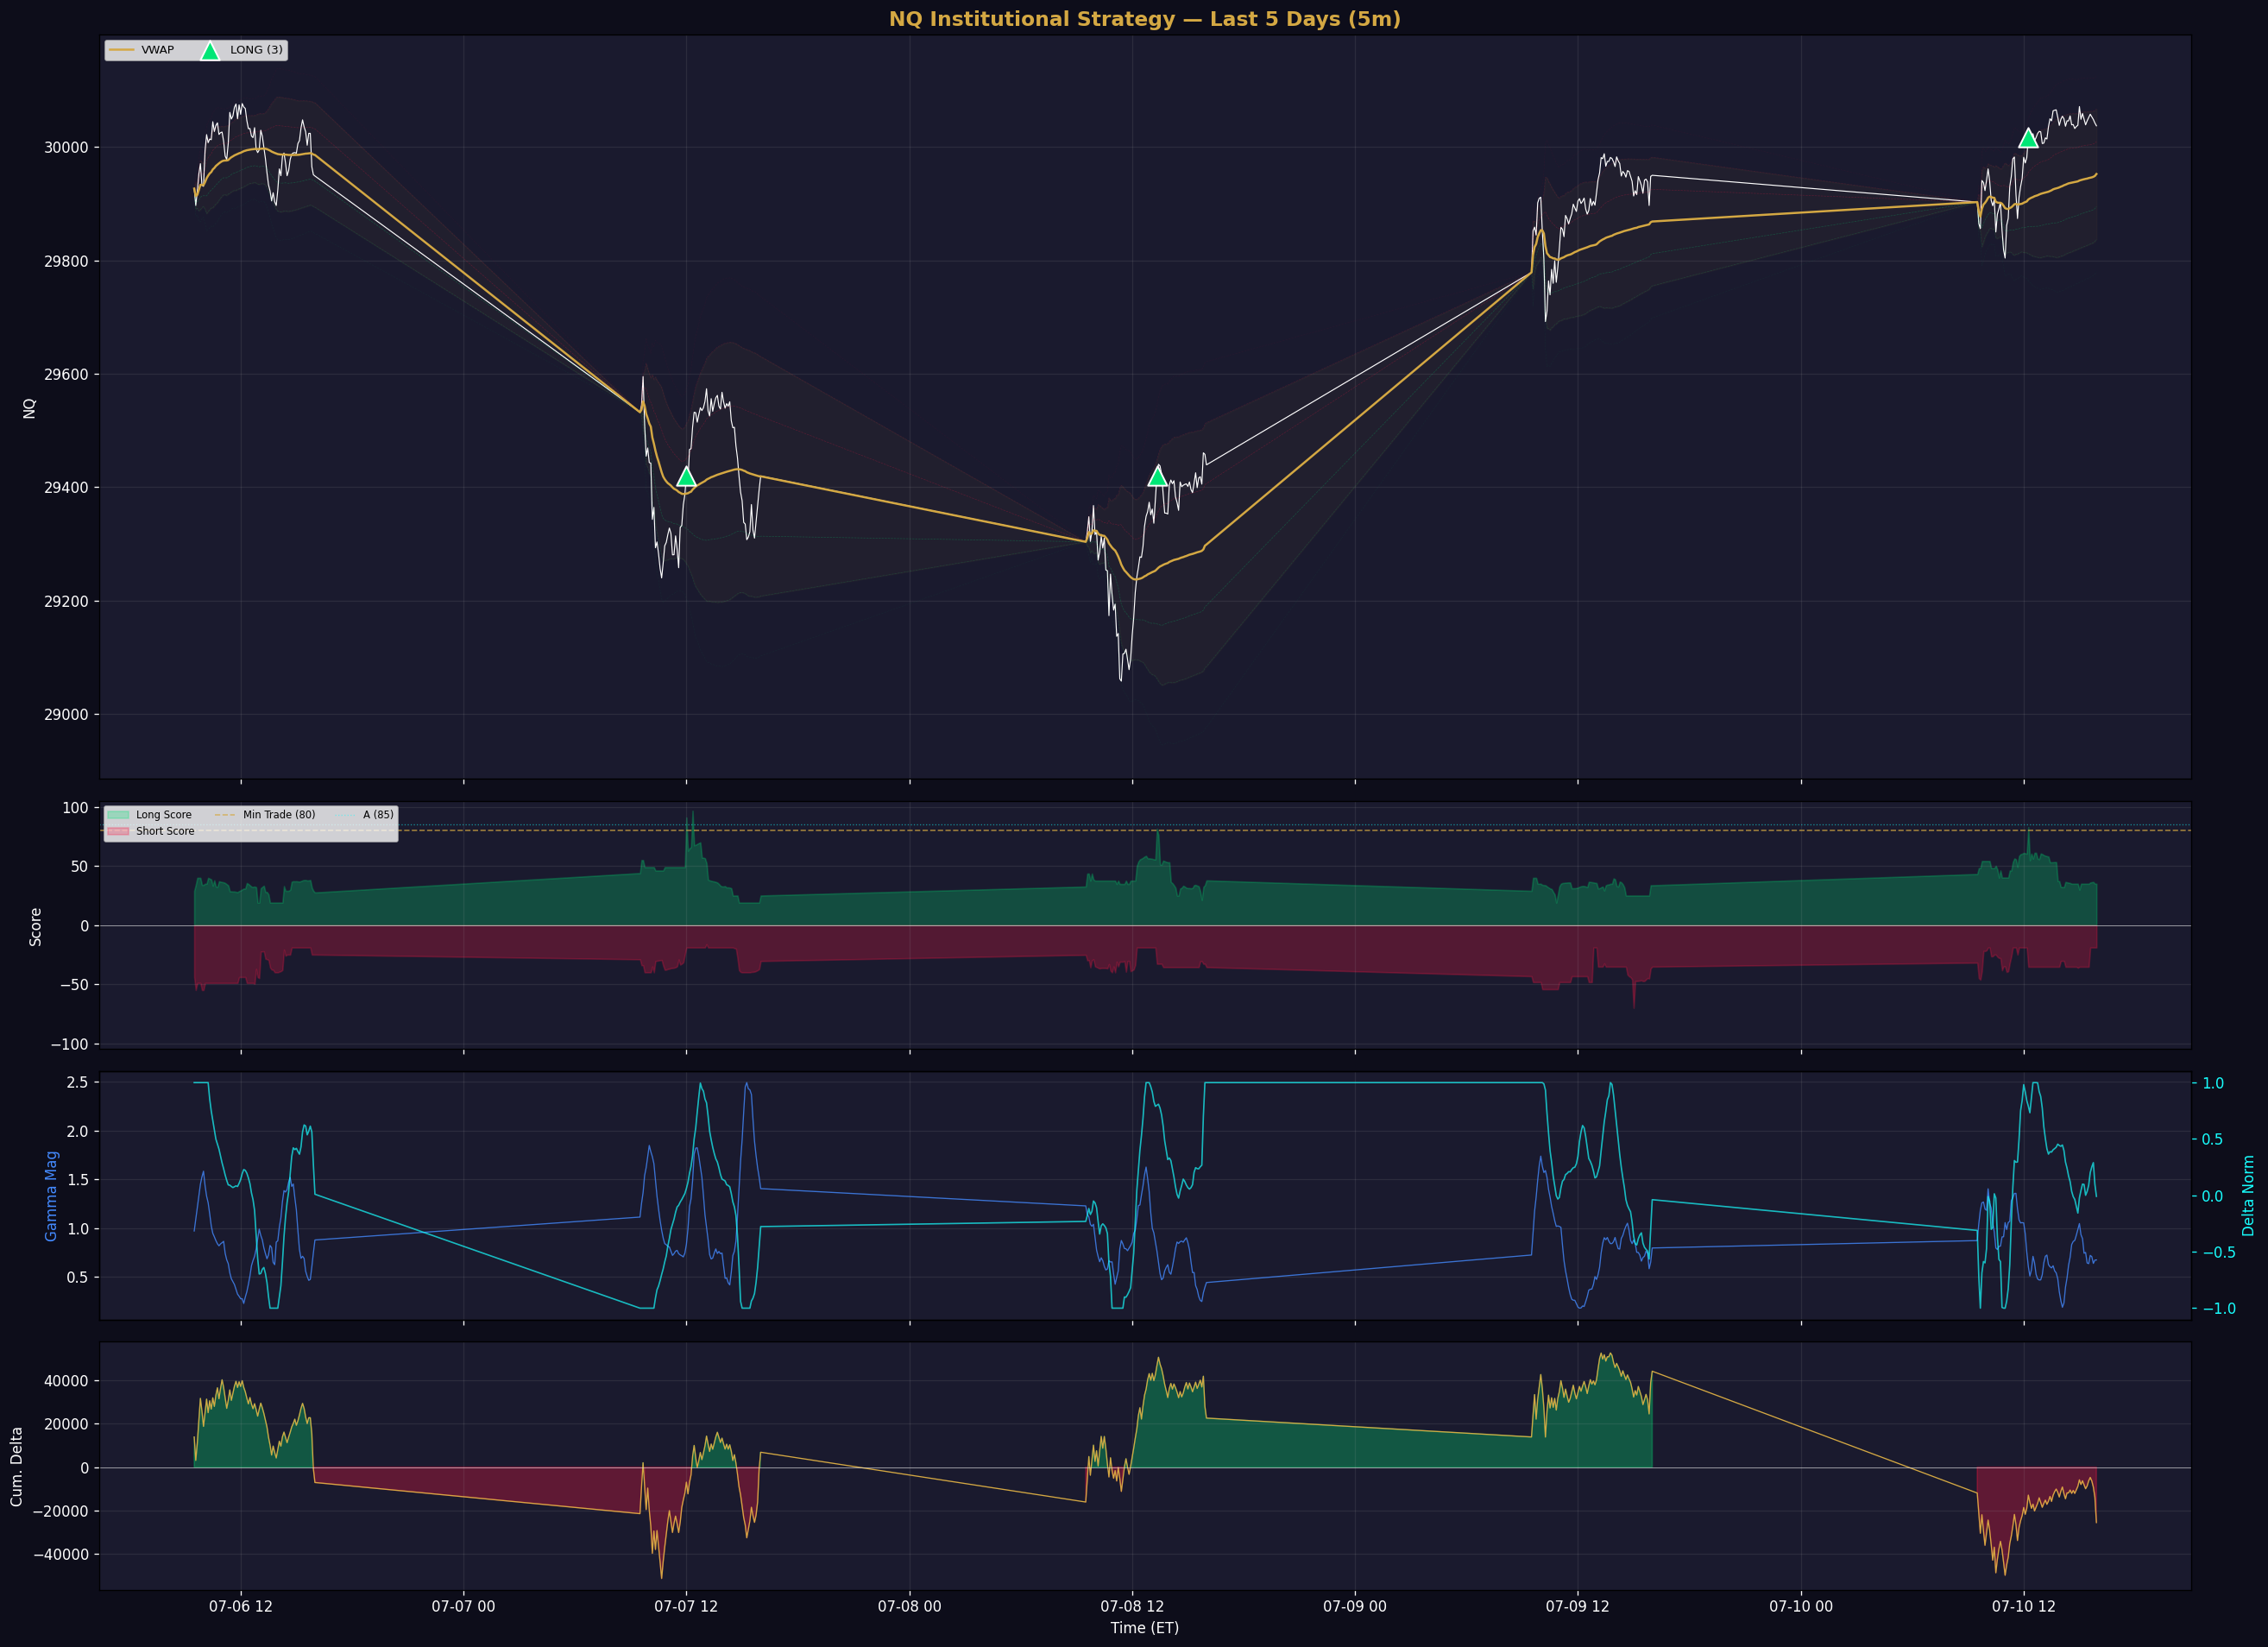

In [13]:
def plot_strategy(df, n_days=5):
    """Multi-panel chart with all strategy components."""
    dates = sorted(set(df.index.date), reverse=True)[:n_days]
    plot = df[pd.Series(df.index.date, index=df.index).isin(dates)]
    if len(plot) == 0:
        return

    GOLD, GRN, RED, BLU, CYAN = '#D4A843', '#00E676', '#FF1744', '#448AFF', '#18FFFF'

    fig, axes = plt.subplots(4, 1, figsize=(22, 16), sharex=True,
                              gridspec_kw={'height_ratios': [3, 1, 1, 1]})
    ax1, ax2, ax3, ax4 = axes
    fig.patch.set_facecolor('#0d0d1a')

    # Panel 1: Price + VWAP + Bands + Signals
    ax1.plot(plot.index, plot['Close'], color='white', lw=0.7, zorder=2)
    ax1.plot(plot.index, plot['vwap'], color=GOLD, lw=1.5, label='VWAP', zorder=3)
    for i in range(1, 4):
        a = 0.35 - i * 0.1
        ax1.plot(plot.index, plot[f'vwap_upper_{i}'], color=RED, lw=0.4, alpha=a, ls='--')
        ax1.plot(plot.index, plot[f'vwap_lower_{i}'], color=GRN, lw=0.4, alpha=a, ls='--')
    ax1.fill_between(plot.index, plot['vwap_upper_2'], plot['vwap_lower_2'], alpha=0.04, color=GOLD)

    ls = plot[plot['signal_long']]
    ss = plot[plot['signal_short']]
    if len(ls) > 0:
        ax1.scatter(ls.index, ls['Close'], color=GRN, marker='^', s=180,
                    edgecolors='white', linewidth=1.2, zorder=5, label=f'LONG ({len(ls)})')
    if len(ss) > 0:
        ax1.scatter(ss.index, ss['Close'], color=RED, marker='v', s=180,
                    edgecolors='white', linewidth=1.2, zorder=5, label=f'SHORT ({len(ss)})')

    ax1.set_ylabel('NQ', color='white')
    ax1.legend(loc='upper left', fontsize=8, ncol=3)
    ax1.set_title(f'NQ Institutional Strategy — Last {n_days} Days ({config.interval})',
                  fontsize=14, fontweight='bold', color=GOLD)
    ax1.grid(True, alpha=0.12)
    ax1.set_facecolor('#1a1a2e'); ax1.tick_params(colors='white')

    # Panel 2: Quality Score
    ax2.fill_between(plot.index, 0, plot['score_long'], color=GRN, alpha=0.25, label='Long Score')
    ax2.fill_between(plot.index, 0, -plot['score_short'], color=RED, alpha=0.25, label='Short Score')
    ax2.axhline(config.min_score_to_trade, color=GOLD, ls='--', lw=1, alpha=0.7,
                label=f'Min Trade ({config.min_score_to_trade})')
    ax2.axhline(config.min_score_a, color=CYAN, ls=':', lw=0.8, alpha=0.5, label=f'A ({config.min_score_a})')
    ax2.axhline(0, color='white', lw=0.3)
    ax2.set_ylabel('Score', color='white')
    ax2.legend(loc='upper left', fontsize=7, ncol=3)
    ax2.grid(True, alpha=0.12)
    ax2.set_facecolor('#1a1a2e'); ax2.tick_params(colors='white')
    ax2.set_ylim(-105, 105)

    # Panel 3: Greeks — Gamma Magnitude + Delta Norm
    ax3.plot(plot.index, plot['gamma_magnitude'], color=BLU, lw=0.8, alpha=0.8, label='Gamma Mag')
    ax3t = ax3.twinx()
    ax3t.plot(plot.index, plot['delta_norm'], color=CYAN, lw=1, alpha=0.7, label='Delta Norm')
    ax3.set_ylabel('Gamma Mag', color=BLU); ax3t.set_ylabel('Delta Norm', color=CYAN)
    ax3.grid(True, alpha=0.12)
    ax3.set_facecolor('#1a1a2e'); ax3.tick_params(colors='white'); ax3t.tick_params(colors=CYAN)

    # Panel 4: Cumulative Delta (Institutional Flow)
    ax4.fill_between(plot.index, 0, plot['cumulative_delta'],
                     where=plot['cumulative_delta'] >= 0, color=GRN, alpha=0.3)
    ax4.fill_between(plot.index, 0, plot['cumulative_delta'],
                     where=plot['cumulative_delta'] < 0, color=RED, alpha=0.3)
    ax4.plot(plot.index, plot['cumulative_delta'], color=GOLD, lw=0.8)
    ax4.axhline(0, color='white', lw=0.3)
    ax4.set_ylabel('Cum. Delta', color='white')
    ax4.set_xlabel('Time (ET)', color='white')
    ax4.grid(True, alpha=0.12)
    ax4.set_facecolor('#1a1a2e'); ax4.tick_params(colors='white')

    plt.tight_layout()
    plt.show()


plot_strategy(df_nq, n_days=5)

## 12. Curva de Equity & Estatisticas Avancadas

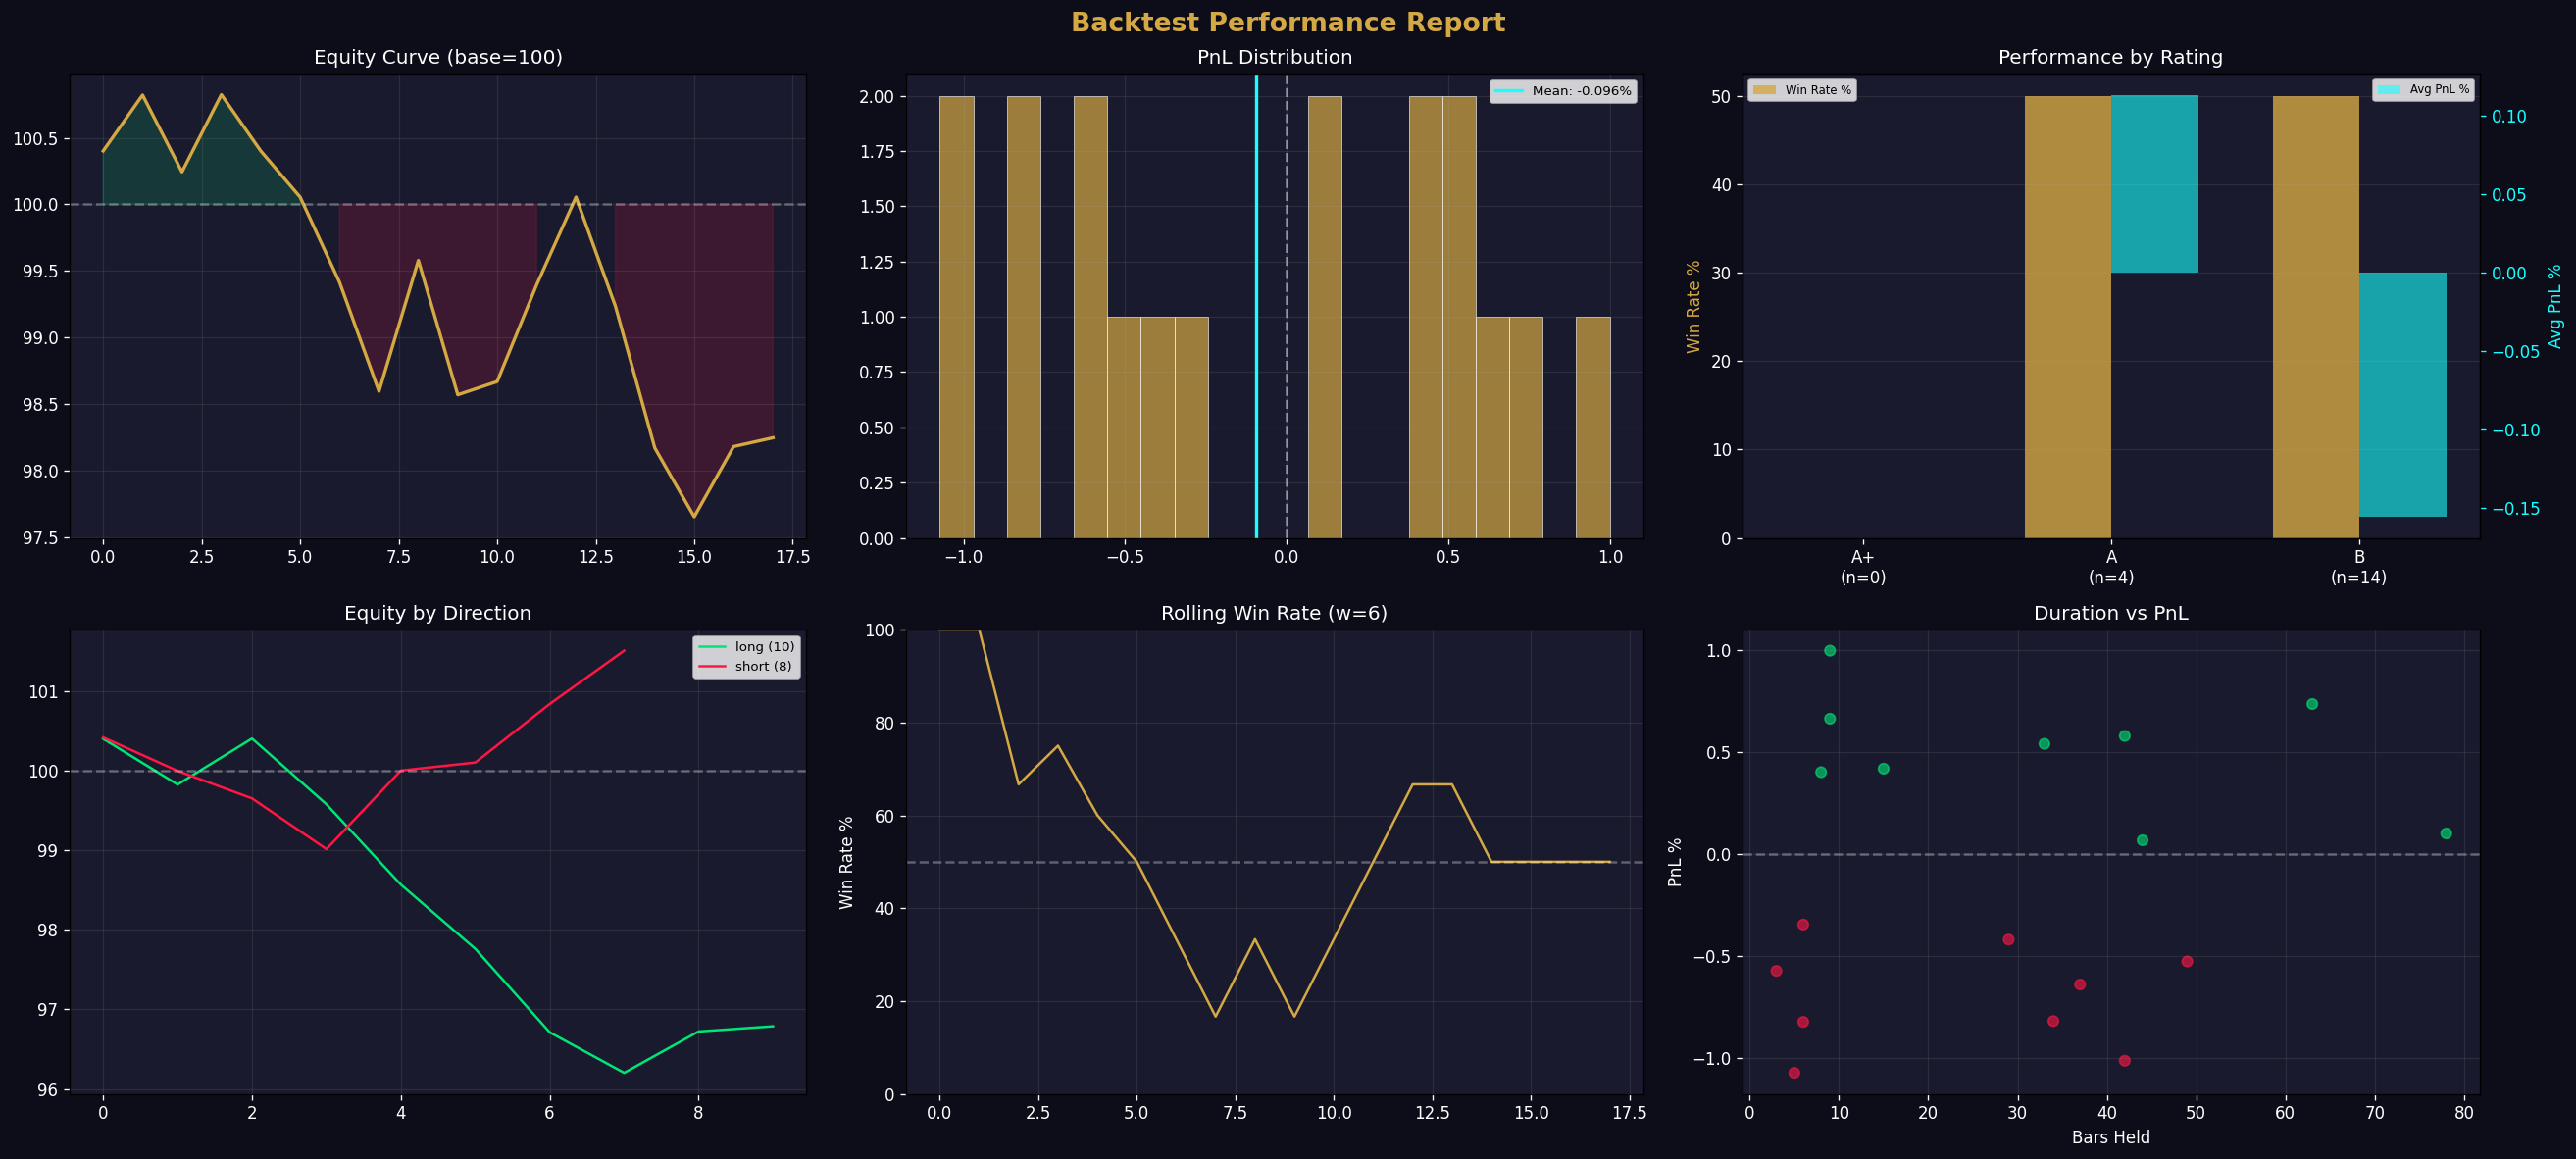

In [14]:
if len(trades_df) > 1:
    GOLD, GRN, RED, CYAN = '#D4A843', '#00E676', '#FF1744', '#18FFFF'

    fig, axes = plt.subplots(2, 3, figsize=(22, 10))
    fig.suptitle('Backtest Performance Report', fontsize=16, fontweight='bold', color=GOLD)
    fig.patch.set_facecolor('#0d0d1a')

    # 1. Equity Curve
    ax = axes[0, 0]
    eq = (1 + trades_df['pnl_pct'] / 100).cumprod() * 100
    ax.plot(range(len(eq)), eq.values, color=GOLD, lw=2)
    ax.fill_between(range(len(eq)), 100, eq.values, where=eq.values >= 100, color=GRN, alpha=0.15)
    ax.fill_between(range(len(eq)), 100, eq.values, where=eq.values < 100, color=RED, alpha=0.15)
    ax.axhline(100, color='white', ls='--', alpha=0.3)
    ax.set_title('Equity Curve (base=100)', color='white')
    ax.grid(True, alpha=0.12)
    ax.set_facecolor('#1a1a2e'); ax.tick_params(colors='white')

    # 2. PnL Distribution
    ax = axes[0, 1]
    ax.hist(trades_df['pnl_pct'], bins=20, color=GOLD, alpha=0.7, edgecolor='white', lw=0.5)
    ax.axvline(0, color='white', ls='--', alpha=0.5)
    ax.axvline(trades_df['pnl_pct'].mean(), color=CYAN, lw=2,
              label=f'Mean: {trades_df["pnl_pct"].mean():.3f}%')
    ax.set_title('PnL Distribution', color='white')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.12)
    ax.set_facecolor('#1a1a2e'); ax.tick_params(colors='white')

    # 3. Win Rate by Rating
    ax = axes[0, 2]
    ratings = ['A+', 'A', 'B']
    wr_vals, avg_vals, counts = [], [], []
    for r in ratings:
        s = trades_df[trades_df['rating'] == r]
        counts.append(len(s))
        wr_vals.append((s['pnl_pct'] > 0).mean() * 100 if len(s) > 0 else 0)
        avg_vals.append(s['pnl_pct'].mean() if len(s) > 0 else 0)
    x = np.arange(len(ratings)); w = 0.35
    ax.bar(x - w/2, wr_vals, w, color=GOLD, alpha=0.8, label='Win Rate %')
    axt = ax.twinx()
    axt.bar(x + w/2, avg_vals, w, color=CYAN, alpha=0.6, label='Avg PnL %')
    ax.set_xticks(x)
    ax.set_xticklabels([f'{r}\n(n={c})' for r, c in zip(ratings, counts)])
    ax.set_ylabel('Win Rate %', color=GOLD)
    axt.set_ylabel('Avg PnL %', color=CYAN)
    ax.set_title('Performance by Rating', color='white')
    ax.legend(loc='upper left', fontsize=7); axt.legend(loc='upper right', fontsize=7)
    ax.grid(True, alpha=0.12, axis='y')
    ax.set_facecolor('#1a1a2e'); ax.tick_params(colors='white'); axt.tick_params(colors=CYAN)

    # 4. Equity by Direction
    ax = axes[1, 0]
    for d, c in [('long', GRN), ('short', RED)]:
        s = trades_df[trades_df['direction'] == d].reset_index(drop=True)
        if len(s) > 0:
            ceq = (1 + s['pnl_pct'] / 100).cumprod() * 100
            ax.plot(range(len(ceq)), ceq.values, color=c, lw=1.5, label=f'{d} ({len(s)})')
    ax.axhline(100, color='white', ls='--', alpha=0.3)
    ax.set_title('Equity by Direction', color='white')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.12)
    ax.set_facecolor('#1a1a2e'); ax.tick_params(colors='white')

    # 5. Rolling Win Rate
    ax = axes[1, 1]
    window = max(5, len(trades_df) // 3)
    rolling_wr = trades_df['pnl_pct'].gt(0).rolling(window, min_periods=1).mean() * 100
    ax.plot(range(len(rolling_wr)), rolling_wr.values, color=GOLD, lw=1.5)
    ax.axhline(50, color='white', ls='--', alpha=0.3)
    ax.set_title(f'Rolling Win Rate (w={window})', color='white')
    ax.set_ylabel('Win Rate %', color='white')
    ax.grid(True, alpha=0.12)
    ax.set_facecolor('#1a1a2e'); ax.tick_params(colors='white')
    ax.set_ylim(0, 100)

    # 6. Duration vs PnL
    ax = axes[1, 2]
    colors_pnl = [GRN if p > 0 else RED for p in trades_df['pnl_pct']]
    ax.scatter(trades_df['bars_held'], trades_df['pnl_pct'], c=colors_pnl, alpha=0.6, s=40)
    ax.axhline(0, color='white', ls='--', alpha=0.3)
    ax.set_xlabel('Bars Held', color='white')
    ax.set_ylabel('PnL %', color='white')
    ax.set_title('Duration vs PnL', color='white')
    ax.grid(True, alpha=0.12)
    ax.set_facecolor('#1a1a2e'); ax.tick_params(colors='white')

    plt.tight_layout()
    plt.show()
else:
    print('Not enough trades for analytics')

## 13. Tabela de Sinais Recentes

In [15]:
if len(trades_df) > 0:
    display = trades_df[['entry_time', 'direction', 'entry_price', 'exit_price',
                          'pnl_pct', 'exit_reason', 'bars_held', 'score', 'rating']].copy()
    display['pnl_pct'] = display['pnl_pct'].round(3)
    display['entry_price'] = display['entry_price'].round(2)
    display['exit_price'] = display['exit_price'].round(2)
    display['score'] = display['score'].round(0).astype(int)

    print('All trades:')
    print(display.to_string(index=False))

All trades:
         entry_time direction  entry_price  exit_price  pnl_pct exit_reason  bars_held  score rating
2026-05-12 15:10:00      long     29040.00    29156.59    0.401      target          8     85      B
2026-05-15 15:50:00     short     29234.75    29112.37    0.419      target         15     82      B
2026-05-18 15:50:00      long     29107.75    28940.94   -0.573        stop          3     83      B
2026-05-19 12:50:00      long     29023.50    29191.60    0.579      target         42     84      B
2026-05-26 11:50:00     short     29909.75    30035.25   -0.420        stop         29     94      A
2026-05-28 09:40:00     short     29955.50    30059.05   -0.346        stop          6     81      B
2026-06-08 13:00:00     short     29518.50    29707.35   -0.640        stop         37     84      B
2026-06-09 09:40:00      long     29767.00    29521.95   -0.823        stop          6     82      B
2026-06-09 10:40:00     short     29286.25    28994.16    0.997      target    

## 14. Resumo & Guia de Otimizacao

### Componentes implementados

| Componente | Metodo |
|---|---|
| **VWAP** | Ancorado diariamente, bandas de desvio padrao expansivo |
| **Delta Hedging** | Cumulative Volume Delta (Tick Rule) reset diario |
| **Delta Proxy** | Momentum normalizado (1a derivada do preco) |
| **Gamma Proxy** | Aceleracao (2a derivada) — regioes de alto gamma |
| **Vanna Proxy** | Sensibilidade delta × variacao de volatilidade |
| **Liquidez** | Sweep de swings + validacao de wick + recaptura rapida |
| **MSB** | Rompimento de estrutura pos-captura de liquidez |
| **SPY/QQQ** | Alinhamento direcional + espaco para movimento |
| **Scoring** | Ponderado por qualidade (0-100) com rating A+/A/B |

### Parametros para ajuste

| Parametro | Efeito | Sugestao |
|---|---|---|
| `min_score_to_trade` | Aumente → menos sinais, mais qualidade | Testar 85-90 |
| `signal_cooldown_bars` | Aumente → menos sinais consecutivos | Testar 20-30 |
| `stop_mult` | Aumente → stops mais largos, menos whipsaws | Testar 2.5x ATR |
| `target_mult` | Aumente → alvos mais distantes, maior R:R | Testar 4x ATR |
| `liq_swing_lookback` | Janela para deteccao de swings | 10-30 |
| `msb_break_pct` | Forca minima da quebra de estrutura | 0.0003-0.001 |
| `interval` | '1m' para mais sinais, '5m' para menos ruido | — |

### Proximos passos
1. Walk-forward optimization com dados out-of-sample
2. Adicionar regime filter (HMM) para evitar mercados laterais
3. Implementar Charm proxy com peso por hora do dia
4. Adicionar confirmacao de volume no MSB
5. Testar em diferentes regimes de volatilidade (VIX)

In [16]:
if len(trades_df) > 0:
    out_dir = Path('backtest_images')
    out_dir.mkdir(exist_ok=True)
    trades_df.to_csv(out_dir / 'nasdaq_institutional_signals.csv', index=False)
    print(f'Signals exported to {out_dir / "nasdaq_institutional_signals.csv"}')

print(f'\nCurrent Strategy Config:')
for k, v in sorted(config.__dict__.items()):
    if not k.startswith('_'):
        print(f'  {k}: {v}')

print('\nNotebook concluido.')

Signals exported to backtest_images/nasdaq_institutional_signals.csv

Current Strategy Config:
  atr_period: 14
  confirm_qqq: QQQ
  confirm_spy: SPY
  delta_period: 10
  dh_lookback: 20
  gamma_period: 10
  interval: 5m
  liq_min_wick_pct: 0.0008
  liq_recapture_bars: 5
  liq_swing_lookback: 20
  lookback_days: 59
  market_close: 16:00
  market_open: 09:30
  max_trade_bars: 78
  min_score_a: 85
  min_score_a_plus: 95
  min_score_to_trade: 80
  msb_break_pct: 0.0005
  msb_swing_lookback: 20
  primary: NQ=F
  score_liquidity: 30
  score_momentum: 5
  score_qqq_aligned: 5
  score_spy_aligned: 10
  score_structure_break: 30
  score_vwap_quality: 20
  signal_cooldown_bars: 15
  stop_mult: 2.0
  target_mult: 3.0
  vanna_period: 20
  vwap_band_std: 1.0
  vwap_num_bands: 3

Notebook concluido.
